<a href="https://colab.research.google.com/github/MiguelRayan/AnaliseDados-VarClimatica-X-Estoque-regiao-/blob/main/ACEAdados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### **Introdução**
A produção agrícola brasileira está sujeita a diversas variáveis, entre elas fatores climáticos como temperatura e precipitação. Essas variáveis podem influenciar o desempenho das safras e, consequentemente, os níveis de estoque de commodities agrícolas ao longo do tempo.

Diante disso, surge a seguinte questão de pesquisa:
Qual a associação entre temperatura média, precipitação acumulada e os níveis de estoque de commodities agrícolas nas regiões brasileiras no período de 2018 a 2024?

É importante destacar que o objetivo não é estabelecer relações de causa e efeito, mas sim identificar possíveis padrões de associação entre as variáveis analisadas.

## **Contextualização e referências**

IBGE / SIDRA: responsável por disponibilizar dados oficiais de estoques de produtos agrícolas, organizados por região, unidade federativa e período;
INMET (BDMEP): fornece dados meteorológicos históricos, como temperatura e precipitação, coletados em estações distribuídas pelo território nacional.

A análise concentra-se em variáveis climáticas agregadas por unidade federativa e por semestre, compatibilizando a escala temporal com os dados de estoque agrícola. Serão consideradas commodities relevantes disponíveis na base do SIDRA, como soja, milho, arroz, trigo e café, permitindo uma análise comparativa entre diferentes culturas.

## **Metodologia**

https://sidra.ibge.gov.br/tabela/254

https://tempo.inmet.gov.br/TabelaEstacoes/A001

Período = os dados estão sendo avaliados de 2018 até 2024

Variáveis = nível de estocagem anual (SIDRA) e variações climáticas mensais (INMET). As variáveis climáticas, originalmente mensais, foram agregadas por semestre, utilizando:
média semestral para temperatura;
soma semestral para precipitação.

Critérios = Utilização de commodities relevantes e recorrentes na base, como soja, milho, arroz, trigo e café;
Consideração de dados válidos, excluindo registros com valores ausentes, inconsistentes ou marcados como “X”, “-” ou similares;
Limitação do período de análise entre 2018 e 2024.

Etapas de tratamento = Leitura e estruturação dos dados; Limpeza dos dados; Transformação dos dados; Integração das bases; Validação.

Ferramentas e método de modelagem = Pandas e NumPy para manipulação e tratamento de dados;

Matplotlib e Seaborn para visualização gráfica;

DuckDB para consultas SQL e armazenamento em formato analítico;

Scikit-learn para modelagem estatística.

In [28]:
!pip install pandas duckdb pyarrow scikit-learn matplotlib seaborn openpyxl ipywidgets

import pandas as pd
import numpy as np
import duckdb
import os
import re
import time
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

from google.colab import drive
import ipywidgets as widgets
from IPython.display import display

warnings.filterwarnings("ignore")

drive.mount('/content/drive')

caminho_sidra = '/content/drive/MyDrive/ACEA dados/base_dados_sidra.xlsx'
caminho_bdmep = '/content/drive/MyDrive/ACEA dados/base dados bdmep/dados INMET'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [29]:
def carregar_sidra(caminho):

    xls = pd.ExcelFile(caminho)
    dfs = []

    REGIOES = ['Norte','Nordeste','Sudeste','Sul','Centro-Oeste']

    for aba in xls.sheet_names:

        if "Tabela" not in aba:
            continue

        df = pd.read_excel(caminho, sheet_name=aba, skiprows=6)

        df.rename(columns={df.columns[0]: 'regiao'}, inplace=True)
        df = df[df['regiao'].isin(REGIOES)]

        header = pd.read_excel(caminho, sheet_name=aba, nrows=5, header=None)
        texto = " ".join(header.astype(str).values.flatten())

        ano = int(re.search(r'\d{4}', texto).group())
        semestre = 1 if '1º' in texto else 2

        df['ano'] = ano
        df['semestre'] = semestre

        df = df.replace(['X','-','..'], np.nan)
        df = df.infer_objects(copy=False)

        df_melt = df.melt(
            id_vars=['regiao','ano','semestre'],
            var_name='produto',
            value_name='estoque'
        )

        df_melt['estoque'] = pd.to_numeric(df_melt['estoque'], errors='coerce')

        dfs.append(df_melt)

    df = pd.concat(dfs, ignore_index=True)
    df = df.dropna(subset=['estoque'])

    print("SIDRA:", df.shape)
    return df

In [30]:
def carregar_inmet(caminho):

    arquivos = os.listdir(caminho)
    dfs = []

    mapa_estacoes = {
    "A881": "RS",
    "A022": "GO",
    "A042": "GO",
    "A121": "AM",
    "A226": "PA",
    "A314": "CE",
    "A410": "BA",
    "A609": "RJ",
    "A708": "SP",
    "A875": "PR",
    "A104": "AC",
    "A201": "PA",
    "A231": "PA",
    "A209": "PA",
    "A009": "TO",
    "A418": "BA",
    "A203": "MA",
    "A301": "PE",
    "A816": "SC",
    "A622": "ES",
    "A564": "MG",
    "A555": "MG",
    "A001": "DF",
    "A926": "MT"
}

    for arq in arquivos:

        if not arq.endswith('.csv'):
            continue

        try:
            df = pd.read_csv(
                os.path.join(caminho, arq),
                sep=';', encoding='latin1', skiprows=10
            )

            df = df.iloc[:, :3]
            df.columns = ['data','precipitacao','temperatura']

            df['data'] = pd.to_datetime(df['data'], errors='coerce')

            df['precipitacao'] = pd.to_numeric(
                df['precipitacao'].astype(str).str.replace(',', '.'),
                errors='coerce'
            )

            df['temperatura'] = pd.to_numeric(
                df['temperatura'].astype(str).str.replace(',', '.'),
                errors='coerce'
            )

            # tratar possíveis valores absurdos
            df.loc[(df['temperatura'] < 5) | (df['temperatura'] > 40), 'temperatura'] = np.nan
            df.loc[(df['precipitacao'] < 0) | (df['precipitacao'] > 3000), 'precipitacao'] = np.nan

            codigo = None
            for p in arq.split('_'):
                if p.startswith('A') and p[1:].isdigit():
                    codigo = p

            estado = mapa_estacoes.get(codigo)
            if estado is None:
                continue

            df['estado'] = estado

            df['ano'] = df['data'].dt.year
            df['semestre'] = df['data'].dt.month.apply(lambda x: 1 if x <= 6 else 2)

            dfs.append(df)

        except:
            continue

    df = pd.concat(dfs, ignore_index=True)

    df = df.groupby(['estado','ano','semestre']).agg({
        'temperatura':'mean',
        'precipitacao':'sum'
    }).reset_index()

    print("INMET:", df.shape)
    return df

In [31]:
def preparar_dados(df_clima, df_estoque):

    mapa = {
        "RS":"Sul","PR":"Sul",
        "SP":"Sudeste","RJ":"Sudeste",
        "BA":"Nordeste","CE":"Nordeste",
        "GO":"Centro-Oeste",
        "AM":"Norte","PA":"Norte"
    }

    df_clima['regiao'] = df_clima['estado'].map(mapa)

    df_regiao = df_clima.groupby(['regiao','ano','semestre']).agg({
        'temperatura':'mean',
        'precipitacao':'sum'
    }).reset_index()

    df_regiao.rename(columns={'temperatura':'temperatura_media'}, inplace=True)

    df = pd.merge(df_estoque, df_regiao,
                  on=['regiao','ano','semestre'])

    df['estoque_log'] = np.log1p(df['estoque'])

    print("FINAL:", df.shape)
    return df

In [32]:
def tabela_estatisticas(df):

    mediana = df.median(numeric_only=True)
    cv = df.std(numeric_only=True) / df.mean(numeric_only=True)

    tabela = pd.DataFrame({
        'Mediana': mediana,
        'Coef. Variação': cv
    }).round(3)

    print("\nESTATÍSTICAS")
    display(tabela)

In [33]:
def tabela_correlacao(df):

    corr = df[['estoque','temperatura_media','precipitacao']].corr()

    print("\nCORRELAÇÃO")
    display(corr.round(3))

In [34]:
def tabela_estoque(df):

    tabela = df.groupby(['ano','regiao'])['estoque'].sum().reset_index()
    pivot = tabela.pivot(index='ano', columns='regiao', values='estoque')

    print("\nESTOQUE POR REGIÃO")
    display(pivot.round(0))

In [35]:
def tabela_clima(df):

    tabela = df.groupby('ano').agg({
        'temperatura_media':'mean',
        'precipitacao':'mean'
    }).round(2)

    print("\nCLIMA MÉDIO")
    display(tabela)

In [36]:
def tabela_relacao(df):

    tabela = df.groupby('regiao').agg({
        'estoque':'mean',
        'temperatura_media':'mean',
        'precipitacao':'mean'
    }).reset_index().round(2)

    print("\nRELAÇÃO CLIMA x ESTOQUE")
    display(tabela.sort_values('estoque', ascending=False))

In [37]:
def tabela_interativa(df):

    dropdown = widgets.Dropdown(
        options=sorted(df['regiao'].unique()),
        description='Região:'
    )

    def filtrar(regiao):
        tabela = df[df['regiao'] == regiao].groupby('ano').agg({
            'estoque':'mean',
            'temperatura_media':'mean',
            'precipitacao':'mean'
        }).round(2)

        display(tabela)

    widgets.interact(filtrar, regiao=dropdown)

In [38]:
def analise_sql(df):

    con = duckdb.connect()
    con.execute("CREATE TABLE dados AS SELECT * FROM df")

    print("\nGROUP BY")
    display(con.execute("""
        SELECT regiao, AVG(estoque) AS media
        FROM dados
        GROUP BY regiao
    """).df())

    print("\nHAVING")
    display(con.execute("""
        SELECT regiao, AVG(estoque) AS media
        FROM dados
        GROUP BY regiao
        HAVING AVG(estoque) > 500000
    """).df())

    print("\nWINDOW")
    display(con.execute("""
        SELECT regiao, estoque,
        RANK() OVER (PARTITION BY regiao ORDER BY estoque DESC) AS ranking
        FROM dados
    """).df().head())

    print("\nJOIN")
    display(con.execute("""
        SELECT a.regiao, a.ano, a.estoque
        FROM dados a
        JOIN dados b
        ON a.regiao = b.regiao AND a.ano = b.ano
        LIMIT 10
    """).df())

    print("\nEXPORT")
    con.execute("COPY dados TO 'dados_sql.parquet' (FORMAT PARQUET)")

In [39]:
def comparar_formatos(df):

    df.to_csv('dados.csv', index=False)
    df.to_parquet('dados.parquet')

    df_csv = pd.read_csv('dados.csv')
    df_parquet = pd.read_parquet('dados.parquet')

    cols = sorted(df.columns)

    df_csv = df_csv[cols].sort_values(cols).reset_index(drop=True)
    df_parquet = df_parquet[cols].sort_values(cols).reset_index(drop=True)

    for col in df_csv.select_dtypes(include=['float']).columns:
        df_csv[col] = df_csv[col].round(4)
        df_parquet[col] = df_parquet[col].round(4)

    print("\nCOMPARAÇÃO")
    print("CSV vs Parquet:", df_csv.equals(df_parquet))

    t0 = time.time()
    pd.read_csv('dados.csv')
    print("Tempo CSV:", round(time.time() - t0, 4))

    t0 = time.time()
    pd.read_parquet('dados.parquet')
    print("Tempo Parquet:", round(time.time() - t0, 4))

In [40]:
def graficos(df):

    df_group = df.groupby(['ano','regiao'])['estoque'].sum().reset_index()

    plt.figure()
    sns.lineplot(data=df_group, x='ano', y='estoque', hue='regiao')
    plt.title("Evolução do estoque")
    plt.show()

    plt.figure()
    sns.scatterplot(data=df, x='temperatura_media', y='estoque', hue='regiao')
    plt.title("Temperatura vs Estoque")
    plt.show()

    plt.figure()
    sns.barplot(data=df.groupby('regiao')['estoque'].mean().reset_index(),
                x='regiao', y='estoque')
    plt.title("Estoque médio por região")
    plt.show()

    plt.figure()
    sns.histplot(df['estoque'], bins=30, kde=True)
    plt.title("Distribuição do estoque")
    plt.show()

    plt.figure()
    sns.boxplot(data=df, x='regiao', y='estoque')
    plt.title("Outliers por região")
    plt.show()

In [41]:
def modelo(df):

    df_model = pd.get_dummies(df, columns=['produto','regiao'])

    X = df_model.drop(columns=['estoque','estoque_log'], errors='ignore')
    y = df_model['estoque']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    print("MAE:", round(mean_absolute_error(y_test, y_pred), 2))

SIDRA: (735, 5)
INMET: (246, 5)
FINAL: (735, 8)

ESTATÍSTICAS


,Mediana,Coef. Variação
ano,2021.000,0.001
semestre,1.000,0.334
estoque,38452.000,2.893
temperatura_media,22.825,0.139
precipitacao,1168.800,0.965
estoque_log,10.557,0.257



CORRELAÇÃO


,estoque,temperatura_media,precipitacao
estoque,1.000,-0.177,-0.081
temperatura_media,-0.177,1.000,0.413
precipitacao,-0.081,0.413,1.000



ESTOQUE POR REGIÃO


...


WINDOW


,regiao,estoque,ranking
0,Sudeste,3020402.0,1
1,Sudeste,2715004.0,2
2,Sudeste,2651582.0,3
3,Sudeste,2423685.0,4
4,Sudeste,2081767.0,5



JOIN


,regiao,ano,estoque
0,Nordeste,2018,18168.0
1,Sudeste,2018,15850.0
2,Sul,2018,4449.0
3,Centro-Oeste,2018,13909.0
4,Norte,2018,184810.0
5,Nordeste,2018,17800.0
6,Sudeste,2018,65937.0
7,Sul,2018,4412283.0
8,Centro-Oeste,2018,258888.0
9,Norte,2018,3416.0



EXPORT

COMPARAÇÃO
CSV vs Parquet: True
Tempo CSV: 0.0086
Tempo Parquet: 0.0045


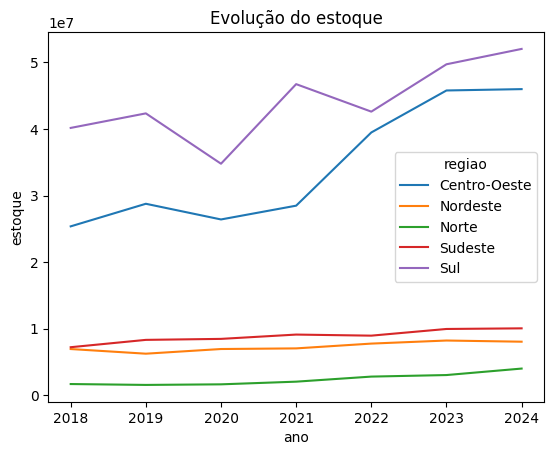

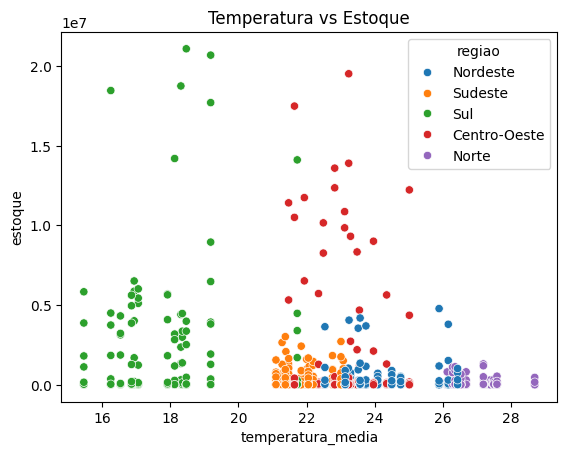

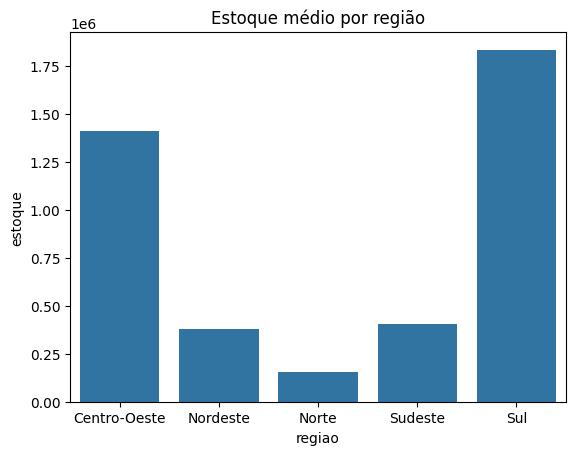

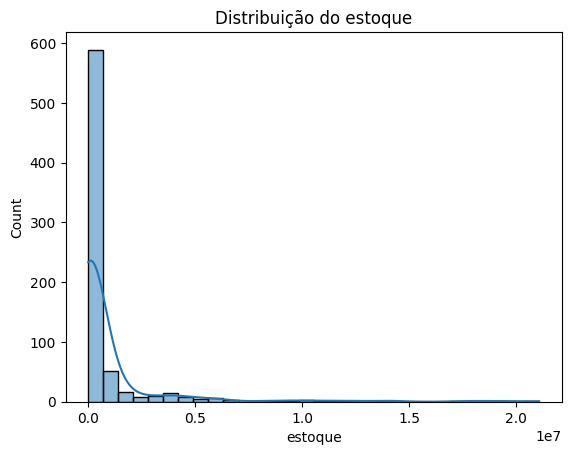

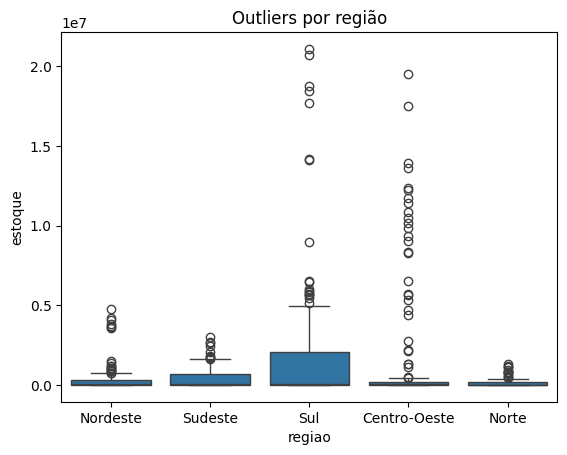

MAE: 1165563.53


In [42]:
df_estoque = carregar_sidra(caminho_sidra)
df_clima = carregar_inmet(caminho_bdmep)

df_final = preparar_dados(df_clima, df_estoque)

tabela_estatisticas(df_final)
tabela_correlacao(df_final)

tabela_estoque(df_final)
tabela_clima(df_final)
tabela_relacao(df_final)

tabela_interativa(df_final)

analise_sql(df_final)
comparar_formatos(df_final)

graficos(df_final)
modelo(df_final)

# **Utilizando Power BI**

# 1 - Gráfico de linha juntando ano, estoque e região

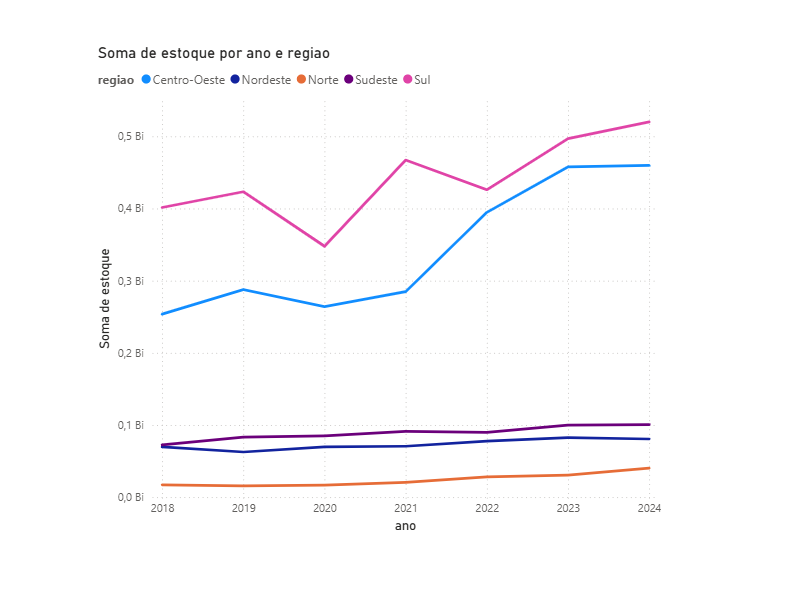

# 2 - Gráfico de barras juntando o estoque por região

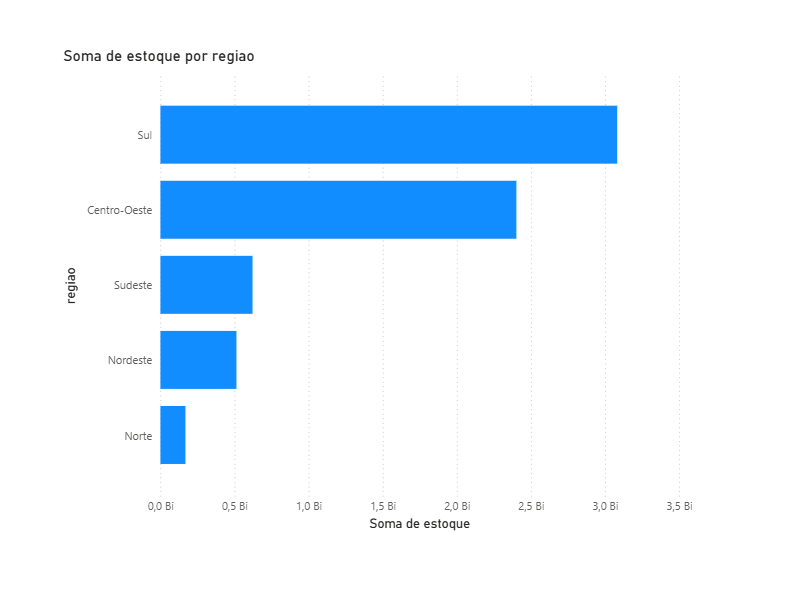

# 3 - Gráfico de dispersão utilizando estoque, temperatura e precipitação média por região

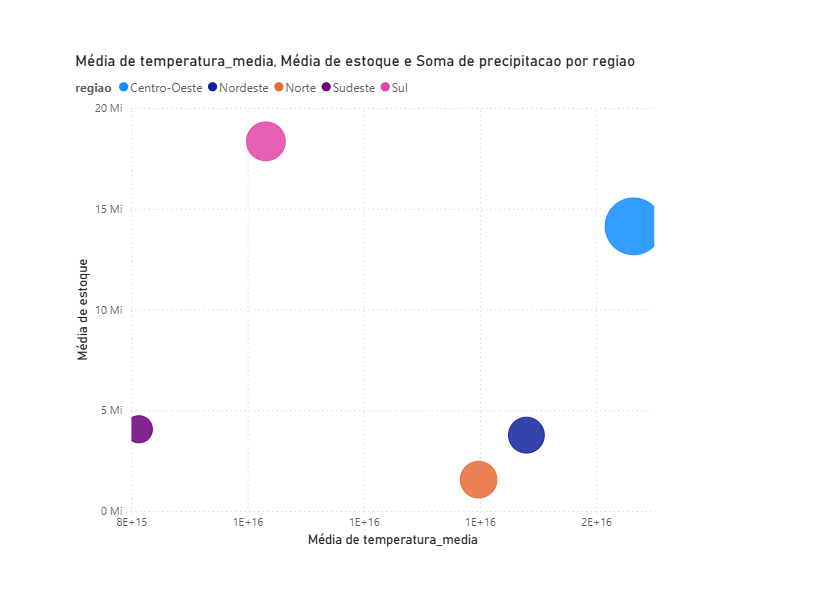

# 4 - Histograma entre entre o estoque

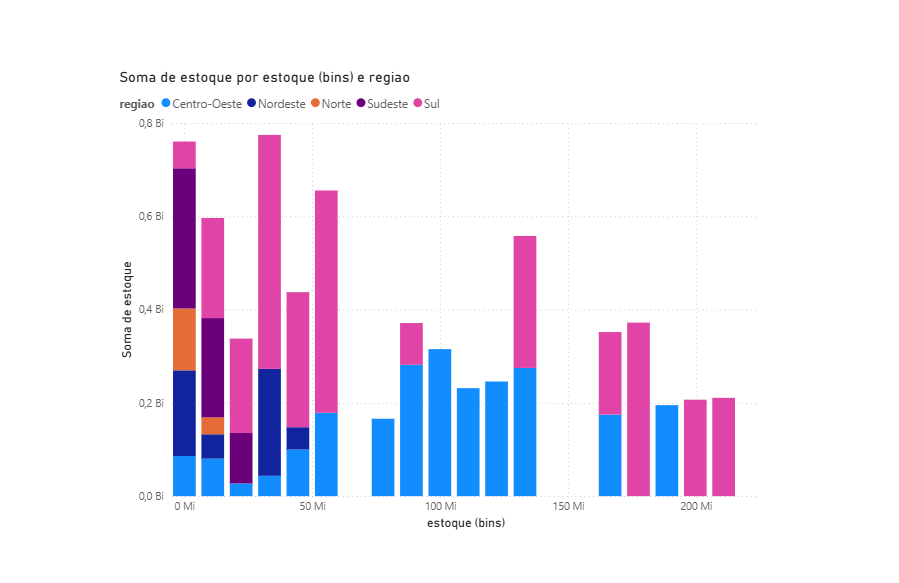